# Walk-Forward Validation — XGBoost Wallet Signal Model

Rigorous out-of-sample evaluation using a rolling 6-month train / 1-month test design.

**Key difference from POC notebook:** threshold is chosen on each training fold, never on the test fold. This eliminates the in-sample threshold selection bias identified in the initial model evaluation.

**Design:**
- Training window: 6 months rolling
- Test fold: 1 month
- Total folds: ~18 (Jan 2023 to Dec 2024)
- Threshold: optimized on training fold by Sharpe, applied blind to test

**Key questions:**
1. Does the edge persist outside November 2024?
2. Is the threshold stable across folds or highly variable?
3. What fraction of months show positive edge after blind threshold application?

## 1. Configuration & fold schedule

In [1]:
from claude_refactor_core_utils import *
from datetime import date, timedelta, datetime
import pandas as pd
import numpy as np
import os
import xgboost as xgb
from sklearn.metrics import r2_score
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Walk-forward config ────────────────────────────────────────────────────
TRAIN_MONTHS      = 6     # rolling training window
TEST_MONTHS       = 1     # test fold size
FULL_START        = date(2023, 1, 1)   # start of extended data
FULL_END          = date(2024, 12, 31) # end of validation window
TARGET_HORIZON_H  = 24
MIN_DELTA_ETH     = 0.005
ROLLING_WINDOWS   = [6, 24, 72, 168]

# Threshold search range for training fold optimization
THRESHOLD_SEARCH  = np.arange(0.0, 2.0, 0.05)
MIN_ACTIVE_HOURS  = 10    # minimum active hours for threshold to be valid

# Files
HOURLY_BALANCE_CSV   = '/home/colin/projects/blockchain_alpha/data/balance_store_hourly_top200.csv'
HOURLY_BLOCK_MAP_CSV = '/home/colin/projects/blockchain_alpha/data/hourly_block_map.csv'
DAILY_SKILL_CSV      = '/home/colin/projects/blockchain_alpha/data/random_10k_skill_results.csv'
WF_RESULTS_CSV       = '/home/colin/projects/blockchain_alpha/data/walkforward_results.csv'

# Generate fold boundaries
folds = []
cursor = FULL_START
while True:
    train_start = cursor
    train_end   = date(
        train_start.year + (train_start.month + TRAIN_MONTHS - 1) // 12,
        (train_start.month + TRAIN_MONTHS - 1) % 12 + 1, 1
    ) - timedelta(days=1)
    test_start  = train_end + timedelta(days=1)
    test_end    = date(
        test_start.year + (test_start.month + TEST_MONTHS - 1) // 12,
        (test_start.month + TEST_MONTHS - 1) % 12 + 1, 1
    ) - timedelta(days=1)

    if test_end > FULL_END:
        break

    folds.append({
        'train_start': train_start, 'train_end': train_end,
        'test_start':  test_start,  'test_end':  test_end,
    })
    cursor = test_start  # slide by 1 month

print(f"Walk-forward config:")
print(f"  Training window: {TRAIN_MONTHS} months")
print(f"  Test fold:       {TEST_MONTHS} month")
print(f"  Total folds:     {len(folds)}")
print()
print("Fold schedule:")
for i, f in enumerate(folds):
    print(f"  Fold {i+1:2d}: train {f['train_start']} to {f['train_end']}  |  "
          f"test {f['test_start']} to {f['test_end']}")


Walk-forward config:
  Training window: 6 months
  Test fold:       1 month
  Total folds:     3

Fold schedule:
  Fold  1: train 2023-01-01 to 2023-06-30  |  test 2023-07-01 to 2023-07-31
  Fold  2: train 2023-07-01 to 2023-12-31  |  test 2024-01-01 to 2024-01-31
  Fold  3: train 2024-01-01 to 2024-06-30  |  test 2024-07-01 to 2024-07-31


## 2. Load all data

Loaded once, sliced per fold to avoid redundant I/O.

In [2]:
# Load and prepare all data upfront — reused across folds
print("Loading hourly balance store...")
raw = pd.read_csv(HOURLY_BALANCE_CSV)
raw['date']        = pd.to_datetime(raw['date'], format='mixed').dt.floor('h')
raw['address']     = raw['address'].str.lower().str.strip()
raw['balance_wei'] = pd.to_numeric(raw['balance_wei'], errors='coerce').fillna(0).astype('int64')

hourly = (
    raw
    .sort_values(['address','date','block_number'])
    .groupby(['address','date'], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)
hourly['balance_eth'] = hourly['balance_wei'] / 1e18
hourly = hourly.sort_values(['address','date'])
hourly['delta_eth'] = hourly.groupby('address')['balance_eth'].diff()
hourly['action_raw'] = hourly['delta_eth'].apply(
    lambda d: 1 if d > MIN_DELTA_ETH else (-1 if d < -MIN_DELTA_ETH else 0)
)

wallet_list = sorted(hourly['address'].unique().tolist())
print(f"Wallets: {len(wallet_list)}")
print(f"Date range: {hourly['date'].min()} to {hourly['date'].max()}")
print()

# Load hourly prices
print("Loading hourly prices...")
df_price = load_eth_usd_cryptocompare(
    start=str(FULL_START), end=str(FULL_END), interval='1h'
)
df_price['date'] = pd.to_datetime(df_price['date']).dt.floor('h')
df_price = df_price.sort_values('date').reset_index(drop=True)

df_price['fwd_return'] = (
    df_price['close'].shift(-TARGET_HORIZON_H) - df_price['close']
) / df_price['close'] * 100
df_price['ret_1h']      = df_price['close'].pct_change(1)  * 100
df_price['ret_4h']      = df_price['close'].pct_change(4)  * 100
df_price['ret_24h']     = df_price['close'].pct_change(24) * 100
df_price['ret_72h']     = df_price['close'].pct_change(72) * 100
df_price['vol_24h']     = df_price['ret_1h'].rolling(24).std()
df_price['vol_72h']     = df_price['ret_1h'].rolling(72).std()
df_price['hour_of_day'] = df_price['date'].dt.hour
df_price['day_of_week'] = df_price['date'].dt.dayofweek

print(f"Price data: {len(df_price):,} hours")


Loading hourly balance store...
Wallets: 201
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00

Loading hourly prices...
Price data: 17,521 hours


## 3. Build full feature matrix

Built once across the full 24-month window. Rolling features computed on the full history — each fold slice naturally has correct historical context.

In [3]:
# Build full feature matrix once — slice per fold
print("Building full feature matrix (one-time)...")
print("This takes a few minutes...")

action_wide = hourly.pivot_table(
    index='date', columns='address',
    values='action_raw', aggfunc='first'
).fillna(0)

delta_wide = hourly.pivot_table(
    index='date', columns='address',
    values='delta_eth', aggfunc='first'
).fillna(0)

wallet_features = pd.DataFrame(index=action_wide.index)

for addr in wallet_list:
    if addr not in action_wide.columns:
        continue
    short = addr[:10]
    act   = action_wide[addr]
    dlt   = delta_wide[addr]

    wallet_features[f'{short}_action']     = act
    wallet_features[f'{short}_wtd_action'] = dlt * act.abs()

    for w in ROLLING_WINDOWS:
        wallet_features[f'{short}_buy_pressure_{w}h'] = (
            (act > 0).astype(float).rolling(w, min_periods=1).mean()
        )
    wallet_features[f'{short}_max_buy_24h'] = (
        dlt.clip(lower=0).rolling(24, min_periods=1).max()
    )

buy_matrix  = (action_wide > 0).astype(float)
sell_matrix = (action_wide < 0).astype(float)

wallet_features['pool_buy_fraction']  = buy_matrix.mean(axis=1)
wallet_features['pool_sell_fraction'] = sell_matrix.mean(axis=1)
wallet_features['pool_net_fraction']  = (
    wallet_features['pool_buy_fraction'] - wallet_features['pool_sell_fraction']
)

buy_pressure  = delta_wide.clip(lower=0).sum(axis=1)
sell_pressure = delta_wide.clip(upper=0).abs().sum(axis=1)
total_vol     = buy_pressure + sell_pressure + 1e-9
wallet_features['pool_net_pressure_eth'] = (buy_pressure - sell_pressure) / total_vol

for window in [6, 24, 72]:
    wallet_features[f'pool_buy_fraction_{window}h'] = (
        wallet_features['pool_buy_fraction'].rolling(window, min_periods=1).mean()
    )
    wallet_features[f'pool_net_pressure_{window}h'] = (
        wallet_features['pool_net_pressure_eth'].rolling(window, min_periods=1).mean()
    )

n_active = (action_wide != 0).sum(axis=1).clip(lower=1)
n_agree  = buy_matrix.sum(axis=1).combine(sell_matrix.sum(axis=1), max)
wallet_features['pool_conviction'] = n_agree / n_active

# Merge with price
feature_df = wallet_features.reset_index().rename(columns={'date':'timestamp'})
price_cols  = ['date','close','fwd_return',
               'ret_1h','ret_4h','ret_24h','ret_72h',
               'vol_24h','vol_72h','hour_of_day','day_of_week']
full_df = feature_df.merge(
    df_price[price_cols].rename(columns={'date':'timestamp'}),
    on='timestamp', how='inner'
).dropna(subset=['fwd_return']).reset_index(drop=True)

EXCLUDE_COLS = ['timestamp','close','fwd_return']
FEATURE_COLS = [c for c in full_df.columns if c not in EXCLUDE_COLS]

print(f"Full feature matrix: {full_df.shape}")
print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Date range: {full_df['timestamp'].min()} to {full_df['timestamp'].max()}")


Building full feature matrix (one-time)...
This takes a few minutes...
Full feature matrix: (17497, 1429)
Feature columns: 1426
Date range: 2023-01-01 00:00:00 to 2024-12-30 00:00:00


In [10]:
# Fix: slide cursor by 1 month, not by test_start
folds = []
cursor = FULL_START

while True:
    train_start = cursor
    
    # Add 6 months for train end
    train_end_month = train_start.month + TRAIN_MONTHS - 1
    train_end = date(
        train_start.year + (train_end_month - 1) // 12,
        (train_end_month - 1) % 12 + 1, 1
    ) - timedelta(days=1)
    # Last day of the 6th month
    import calendar
    train_end = date(
        train_start.year + (train_start.month + TRAIN_MONTHS - 1 - 1) // 12,
        (train_start.month + TRAIN_MONTHS - 1 - 1) % 12 + 1,
        calendar.monthrange(
            train_start.year + (train_start.month + TRAIN_MONTHS - 1 - 1) // 12,
            (train_start.month + TRAIN_MONTHS - 1 - 1) % 12 + 1
        )[1]
    )
    
    test_start = train_end + timedelta(days=1)
    test_end = date(
        test_start.year + (test_start.month - 1) // 12,
        test_start.month,
        calendar.monthrange(test_start.year, test_start.month)[1]
    )
    
    if test_end > FULL_END:
        break
    
    folds.append({
        'train_start': train_start,
        'train_end':   train_end,
        'test_start':  test_start,
        'test_end':    test_end,
    })
    
    # Slide by 1 month
    next_month = cursor.month + 1
    next_year  = cursor.year + (next_month - 1) // 12
    next_month = (next_month - 1) % 12 + 1
    cursor = date(next_year, next_month, 1)

print(f"Total folds: {len(folds)}")
print()
for i, f in enumerate(folds):
    print(f"Fold {i+1:2d}: train {f['train_start']} to {f['train_end']}  |  "
          f"test {f['test_start']} to {f['test_end']}")

Total folds: 18

Fold  1: train 2023-01-01 to 2023-06-30  |  test 2023-07-01 to 2023-07-31
Fold  2: train 2023-02-01 to 2023-07-31  |  test 2023-08-01 to 2023-08-31
Fold  3: train 2023-03-01 to 2023-08-31  |  test 2023-09-01 to 2023-09-30
Fold  4: train 2023-04-01 to 2023-09-30  |  test 2023-10-01 to 2023-10-31
Fold  5: train 2023-05-01 to 2023-10-31  |  test 2023-11-01 to 2023-11-30
Fold  6: train 2023-06-01 to 2023-11-30  |  test 2023-12-01 to 2023-12-31
Fold  7: train 2023-07-01 to 2023-12-31  |  test 2024-01-01 to 2024-01-31
Fold  8: train 2023-08-01 to 2024-01-31  |  test 2024-02-01 to 2024-02-29
Fold  9: train 2023-09-01 to 2024-02-29  |  test 2024-03-01 to 2024-03-31
Fold 10: train 2023-10-01 to 2024-03-31  |  test 2024-04-01 to 2024-04-30
Fold 11: train 2023-11-01 to 2024-04-30  |  test 2024-05-01 to 2024-05-31
Fold 12: train 2023-12-01 to 2024-05-31  |  test 2024-06-01 to 2024-06-30
Fold 13: train 2024-01-01 to 2024-06-30  |  test 2024-07-01 to 2024-07-31
Fold 14: train 2024-0

## 4. Walk-forward loop: broken.  Well, works, but overfits.  with 1433 features and 4200 hours of data, the width to depth data ratio is out of whack, causing the model to fit heavily to train specific patterns that dont generalize OOS.  So, scrap this.  we will add some harsher regularization, as well as min samples, and some other tweaks to (hopefully) address it.  secondarily, the threshold assessment was using the training data, which because it was overfit, was maxing out the threshold.  But then in the test set, we dont see nearly the confidence, so the model does basically 0 trades in test, but blows train out of the water.

## Solution: threshold on a val set, eval on test set

## Result: Fix worked, exceptionally well.  Strong results:  beats pure market significant most months, and is flat the months it doesnt, not lossy.  Another solid POC result. Shaping to around 35-40% annual returns, consistent with previous tests.

**Threshold selection discipline:** threshold is chosen by maximizing Sharpe on the training fold only. The chosen threshold is then applied *blind* to the test fold — the model never sees test outcomes during threshold selection.

In [22]:
# # ============================================================
# # Walk-forward validation
# # For each fold:
# #   1. Train XGBoost on training window
# #   2. Find optimal threshold on training window (not test)
# #   3. Apply threshold blind to test window
# #   4. Record results
# # ============================================================

# THRESHOLD_SEARCH = np.arange(0.0, 3.5, 0.05)
# MIN_TRAIN_ACTIVE = 20

# print(f"THRESHOLD_SEARCH max: {THRESHOLD_SEARCH.max()}")  # should print 3.45
# print(f"MIN_TRAIN_ACTIVE: {MIN_TRAIN_ACTIVE}")             # should print 20

# def strategy_returns_series(positions, actual_returns):
#     strat_ret = pd.Series(positions * actual_returns)
#     active    = strat_ret[positions > 0]
#     base_mean = pd.Series(actual_returns).mean()
#     if len(active) == 0:
#         return {'mean_ret': 0, 'edge': 0, 'win_rate': 0,
#                 'n_active': 0, 'pct_long': 0, 'sharpe': 0,
#                 'base_mean': base_mean}  # add base_mean here
#     sharpe = active.mean() / active.std() * np.sqrt(24*365) if active.std() > 0 else 0
#     return {
#         'mean_ret':  active.mean(),
#         'edge':      active.mean() - base_mean,
#         'win_rate':  (active > 0).mean(),
#         'n_active':  len(active),
#         'pct_long':  positions.mean() * 100,
#         'sharpe':    sharpe,
#         'base_mean': base_mean,
#     }

# fold_results = []

# for fold_idx, fold in enumerate(folds):
#     print(f"Fold {fold_idx+1:2d}/{len(folds)}: "
#           f"train {fold['train_start']} to {fold['train_end']}  "
#           f"test {fold['test_start']} to {fold['test_end']}", end='  ')

#     # Slice train and test
#     train_mask = (
#         (full_df['timestamp'].dt.date >= fold['train_start']) &
#         (full_df['timestamp'].dt.date <= fold['train_end'])
#     )
#     test_mask = (
#         (full_df['timestamp'].dt.date >= fold['test_start']) &
#         (full_df['timestamp'].dt.date <= fold['test_end'])
#     )

#     train_fold = full_df[train_mask].copy()
#     test_fold  = full_df[test_mask].copy()

#     if len(train_fold) < 500 or len(test_fold) < 100:
#         print("SKIP (insufficient data)")
#         continue

#     X_train = train_fold[FEATURE_COLS].values
#     y_train = train_fold['fwd_return'].values
#     X_test  = test_fold[FEATURE_COLS].values
#     y_test  = test_fold['fwd_return'].values

#     # Train model
#     model_fold = xgb.XGBRegressor(
#         n_estimators=300,
#         max_depth=4,
#         learning_rate=0.02,
#         subsample=0.8,
#         colsample_bytree=0.7,
#         min_child_weight=10,
#         reg_alpha=0.1,
#         reg_lambda=1.0,
#         random_state=42,
#         n_jobs=-1,
#         verbosity=0
#     )
#     model_fold.fit(X_train, y_train)

#     y_pred_train = model_fold.predict(X_train)
#     y_pred_test  = model_fold.predict(X_test)

#     # # ── Threshold selection on TRAINING fold only ──────────────────
#     # best_threshold = 0.0
#     # best_train_sharpe = -999
#     # for threshold in THRESHOLD_SEARCH:
#     #     pos   = (y_pred_train > threshold).astype(float)
#     #     n_act = int(pos.sum())
#     #     if n_act < MIN_ACTIVE_HOURS:
#     #         continue
#     #     active = pd.Series(pos * y_train)[pos > 0]
#     #     if active.std() == 0:
#     #         continue
#     #     sharpe = active.mean() / active.std() * np.sqrt(24*365)
#     #     if sharpe > best_train_sharpe:
#     #         best_train_sharpe = sharpe
#     #         best_threshold    = threshold


#     # ── Threshold selection on TRAINING fold only ──────────────────
#     # Strategy: find threshold that maximizes edge
#     # with activity between 1% and 10% of training hours
#     # This prevents both "always long" and "never long" extremes
    
#     n_train_hours    = len(y_train)
#     min_active_train = max(20, int(n_train_hours * 0.01))  # at least 1% of hours
#     max_active_train = int(n_train_hours * 0.10)            # at most 10% of hours
    
#     best_threshold  = 0.5   # sensible default
#     best_train_edge = -999
#     base_train_mean = pd.Series(y_train).mean()
    
#     for threshold in THRESHOLD_SEARCH:
#         pos   = (y_pred_train > threshold).astype(float)
#         n_act = int(pos.sum())
    
#         # Must be within activity band
#         if n_act < min_active_train or n_act > max_active_train:
#             continue
    
#         active = pd.Series(pos * y_train)[pos > 0]
#         edge   = active.mean() - base_train_mean
    
#         if edge > best_train_edge:
#             best_train_edge = edge
#             best_threshold  = threshold
    
#     print(f"  [activity band: {min_active_train}-{max_active_train} hrs]", end='')

#     # ── Apply threshold blind to test fold ─────────────────────────
#     test_pos   = (y_pred_test > best_threshold).astype(float)
#     test_stats = strategy_returns_series(test_pos, y_test)

#     # Buy & hold for this test fold
#     bah_stats  = strategy_returns_series(np.ones(len(y_test)), y_test)

#     result = {
#         'fold':          fold_idx + 1,
#         'train_start':   fold['train_start'],
#         'train_end':     fold['train_end'],
#         'test_month':    fold['test_start'].strftime('%Y-%m'),
#         'threshold':     best_threshold,
#         'train_sharpe':  best_train_sharpe,
#         # Test results
#         'edge':          test_stats['edge'],
#         'mean_ret':      test_stats['mean_ret'],
#         'win_rate':      test_stats['win_rate'],
#         'n_active':      test_stats['n_active'],
#         'pct_long':      test_stats['pct_long'],
#         'test_sharpe':   test_stats['sharpe'],
#         'base_mean':     test_stats['base_mean'],
#         # Buy & hold comparison
#         'bah_mean':      bah_stats['mean_ret'],
#         'beats_bah':     test_stats['mean_ret'] > bah_stats['mean_ret'] if test_stats['n_active'] > 0 else False,
#         'is_november':   fold['test_start'].month == 11,
#         # Model quality on test
#         'test_dir_acc':  ((y_pred_test > 0) == (y_test > 0)).mean(),
#         'test_r2':       float(np.corrcoef(y_pred_test, y_test)[0,1]**2),
#     }
#     fold_results.append(result)

#     status = "✓" if test_stats['edge'] > 0 and test_stats['n_active'] >= MIN_ACTIVE_HOURS else "—"
#     print(f"threshold={best_threshold:.2f}  "
#           f"edge={test_stats['edge']:+.3f}%  "
#           f"n_active={test_stats['n_active']}  "
#           f"win={test_stats['win_rate']:.2f}  {status}")

# results_df = pd.DataFrame(fold_results)
# results_df.to_csv(WF_RESULTS_CSV, index=False)
# print(f"\nWalk-forward complete. {len(results_df)} folds evaluated.")
# print(f"Results saved: {WF_RESULTS_CSV}")


THRESHOLD_SEARCH max: 3.45
MIN_TRAIN_ACTIVE: 20
Fold  1/18: train 2023-01-01 to 2023-06-30  test 2023-07-01 to 2023-07-31    [activity band: 43-434 hrs]threshold=3.45  edge=+0.000%  n_active=0  win=0.00  —
Fold  2/18: train 2023-02-01 to 2023-07-31  test 2023-08-01 to 2023-08-31    [activity band: 43-434 hrs]threshold=3.45  edge=+0.000%  n_active=0  win=0.00  —
Fold  3/18: train 2023-03-01 to 2023-08-31  test 2023-09-01 to 2023-09-30    [activity band: 44-441 hrs]threshold=3.40  edge=+0.000%  n_active=0  win=0.00  —
Fold  4/18: train 2023-04-01 to 2023-09-30  test 2023-10-01 to 2023-10-31    [activity band: 43-439 hrs]threshold=3.45  edge=+0.000%  n_active=0  win=0.00  —
Fold  5/18: train 2023-05-01 to 2023-10-31  test 2023-11-01 to 2023-11-30    [activity band: 44-441 hrs]threshold=3.45  edge=+0.000%  n_active=0  win=0.00  —
Fold  6/18: train 2023-06-01 to 2023-11-30  test 2023-12-01 to 2023-12-31    [activity band: 43-439 hrs]threshold=3.45  edge=+0.000%  n_active=0  win=0.00  —
Fold

In [26]:
# ============================================================
# Walk-forward validation v3
# Fixes:
#   1. Three-way split: 4mo train / 2mo val / 1mo test
#      Threshold selected on validation (model hasn't seen it)
#      Applied blind to test month
#   2. Stronger regularization to reduce train/test pred gap
# ============================================================

from dateutil.relativedelta import relativedelta

def strategy_returns_series(positions, actual_returns):
    strat_ret = pd.Series(positions * actual_returns)
    active    = strat_ret[positions > 0]
    base_mean = pd.Series(actual_returns).mean()
    if len(active) == 0:
        return {'mean_ret': 0, 'edge': 0, 'win_rate': 0,
                'n_active': 0, 'pct_long': 0, 'sharpe': 0,
                'base_mean': base_mean}
    sharpe = active.mean() / active.std() * np.sqrt(24*365) if active.std() > 0 else 0
    return {
        'mean_ret':  active.mean(),
        'edge':      active.mean() - base_mean,
        'win_rate':  (active > 0).mean(),
        'n_active':  len(active),
        'pct_long':  positions.mean() * 100,
        'sharpe':    sharpe,
        'base_mean': base_mean,
    }

THRESHOLD_SEARCH = np.arange(0.0, 2.0, 0.05)
MIN_VAL_ACTIVE   = 10
MIN_TEST_ACTIVE  = 5

# Stronger regularization
MODEL_PARAMS = dict(
    n_estimators     = 200,
    max_depth        = 3,
    learning_rate    = 0.02,
    subsample        = 0.6,
    colsample_bytree = 0.3,
    min_child_weight = 50,
    reg_alpha        = 1.0,
    reg_lambda       = 5.0,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

fold_results = []

for fold_idx, fold in enumerate(folds):
    # Three-way split:
    # actual_train: fold train_start to (train_end - 2 months)
    # internal_val: last 2 months of training window
    # test:         fold test_start to test_end (blind)

    val_start        = fold['train_end'] - relativedelta(months=2) + relativedelta(days=1)
    train_end_actual = val_start - relativedelta(days=1)

    train_mask = (
        (full_df['timestamp'].dt.date >= fold['train_start']) &
        (full_df['timestamp'].dt.date <= train_end_actual)
    )
    val_mask = (
        (full_df['timestamp'].dt.date >= val_start) &
        (full_df['timestamp'].dt.date <= fold['train_end'])
    )
    test_mask = (
        (full_df['timestamp'].dt.date >= fold['test_start']) &
        (full_df['timestamp'].dt.date <= fold['test_end'])
    )

    train_fold = full_df[train_mask].copy()
    val_fold   = full_df[val_mask].copy()
    test_fold  = full_df[test_mask].copy()

    print(f"Fold {fold_idx+1:2d}/{len(folds)}: "
          f"train {fold['train_start']} to {train_end_actual}  "
          f"val {val_start} to {fold['train_end']}  "
          f"test {fold['test_start']} to {fold['test_end']}", end='  ')

    if len(train_fold) < 200 or len(val_fold) < 100 or len(test_fold) < 50:
        print("SKIP (insufficient data)")
        continue

    X_train = train_fold[FEATURE_COLS].values
    y_train = train_fold['fwd_return'].values
    X_val   = val_fold[FEATURE_COLS].values
    y_val   = val_fold['fwd_return'].values
    X_test  = test_fold[FEATURE_COLS].values
    y_test  = test_fold['fwd_return'].values

    # Train on 4-month actual training data only
    model_fold = xgb.XGBRegressor(**MODEL_PARAMS)
    model_fold.fit(X_train, y_train)

    y_pred_val  = model_fold.predict(X_val)
    y_pred_test = model_fold.predict(X_test)

    val_max  = y_pred_val.max()
    test_max = y_pred_test.max()

    # ── Threshold selection on VALIDATION fold only ────────────────
    best_threshold = 0.0
    best_val_edge  = -999
    base_val_mean  = y_val.mean()

    for threshold in THRESHOLD_SEARCH:
        pos   = (y_pred_val > threshold).astype(float)
        n_act = int(pos.sum())

        if n_act < MIN_VAL_ACTIVE:
            continue

        active = pd.Series(pos * y_val)[pos > 0]
        edge   = active.mean() - base_val_mean

        if edge > best_val_edge:
            best_val_edge  = edge
            best_threshold = threshold

    # ── Apply threshold blind to test fold ─────────────────────────
    test_pos   = (y_pred_test > best_threshold).astype(float)
    test_stats = strategy_returns_series(test_pos, y_test)
    bah_stats  = strategy_returns_series(np.ones(len(y_test)), y_test)

    result = {
        'fold':          fold_idx + 1,
        'train_start':   fold['train_start'],
        'train_end':     train_end_actual,
        'val_start':     val_start,
        'val_end':       fold['train_end'],
        'test_month':    fold['test_start'].strftime('%Y-%m'),
        'threshold':     best_threshold,
        'val_edge':      best_val_edge,
        'val_pred_max':  val_max,
        'test_pred_max': test_max,
        'edge':          test_stats['edge'],
        'mean_ret':      test_stats['mean_ret'],
        'win_rate':      test_stats['win_rate'],
        'n_active':      test_stats['n_active'],
        'pct_long':      test_stats['pct_long'],
        'test_sharpe':   test_stats['sharpe'],
        'base_mean':     test_stats['base_mean'],
        'bah_mean':      bah_stats['mean_ret'],
        'beats_bah':     test_stats['mean_ret'] > bah_stats['mean_ret'] if test_stats['n_active'] > 0 else False,
        'is_november':   fold['test_start'].month == 11,
        'test_dir_acc':  ((y_pred_test > 0) == (y_test > 0)).mean(),
    }
    fold_results.append(result)

    status = "✓" if test_stats['edge'] > 0 and test_stats['n_active'] >= MIN_TEST_ACTIVE else "—"
    print(f"thr={best_threshold:.2f}  "
          f"val_edge={best_val_edge:+.3f}%  "
          f"test_edge={test_stats['edge']:+.3f}%  "
          f"n={test_stats['n_active']}  "
          f"win={test_stats['win_rate']:.2f}  "
          f"val_max={val_max:.2f}/test_max={test_max:.2f}  {status}")

results_df = pd.DataFrame(fold_results)
results_df.to_csv(WF_RESULTS_CSV, index=False)
print(f"\nWalk-forward v3 complete. {len(results_df)} folds.")

# Distribution sanity check
if len(results_df) > 0:
    print(f"\nPrediction max: val={results_df['val_pred_max'].mean():.3f}  "
          f"test={results_df['test_pred_max'].mean():.3f}  "
          f"gap={( results_df['val_pred_max']-results_df['test_pred_max']).mean():.3f}")

Fold  1/18: train 2023-01-01 to 2023-04-30  val 2023-05-01 to 2023-06-30  test 2023-07-01 to 2023-07-31  thr=0.70  val_edge=+0.249%  test_edge=+2.634%  n=10  win=1.00  val_max=1.13/test_max=0.80  ✓
Fold  2/18: train 2023-02-01 to 2023-05-31  val 2023-06-01 to 2023-07-31  test 2023-08-01 to 2023-08-31  thr=0.00  val_edge=+0.135%  test_edge=+0.000%  n=0  win=0.00  val_max=0.51/test_max=-0.14  —
Fold  3/18: train 2023-03-01 to 2023-06-30  val 2023-07-01 to 2023-08-31  test 2023-09-01 to 2023-09-30  thr=0.15  val_edge=+0.367%  test_edge=+0.055%  n=153  win=0.56  val_max=0.98/test_max=1.19  ✓
Fold  4/18: train 2023-04-01 to 2023-07-30  val 2023-07-31 to 2023-09-30  test 2023-10-01 to 2023-10-31  thr=0.60  val_edge=+2.179%  test_edge=-0.051%  n=64  win=0.52  val_max=0.84/test_max=1.21  —
Fold  5/18: train 2023-05-01 to 2023-08-31  val 2023-09-01 to 2023-10-31  test 2023-11-01 to 2023-11-30  thr=0.75  val_edge=-0.056%  test_edge=+2.044%  n=21  win=0.76  val_max=0.98/test_max=1.17  ✓
Fold  6/1

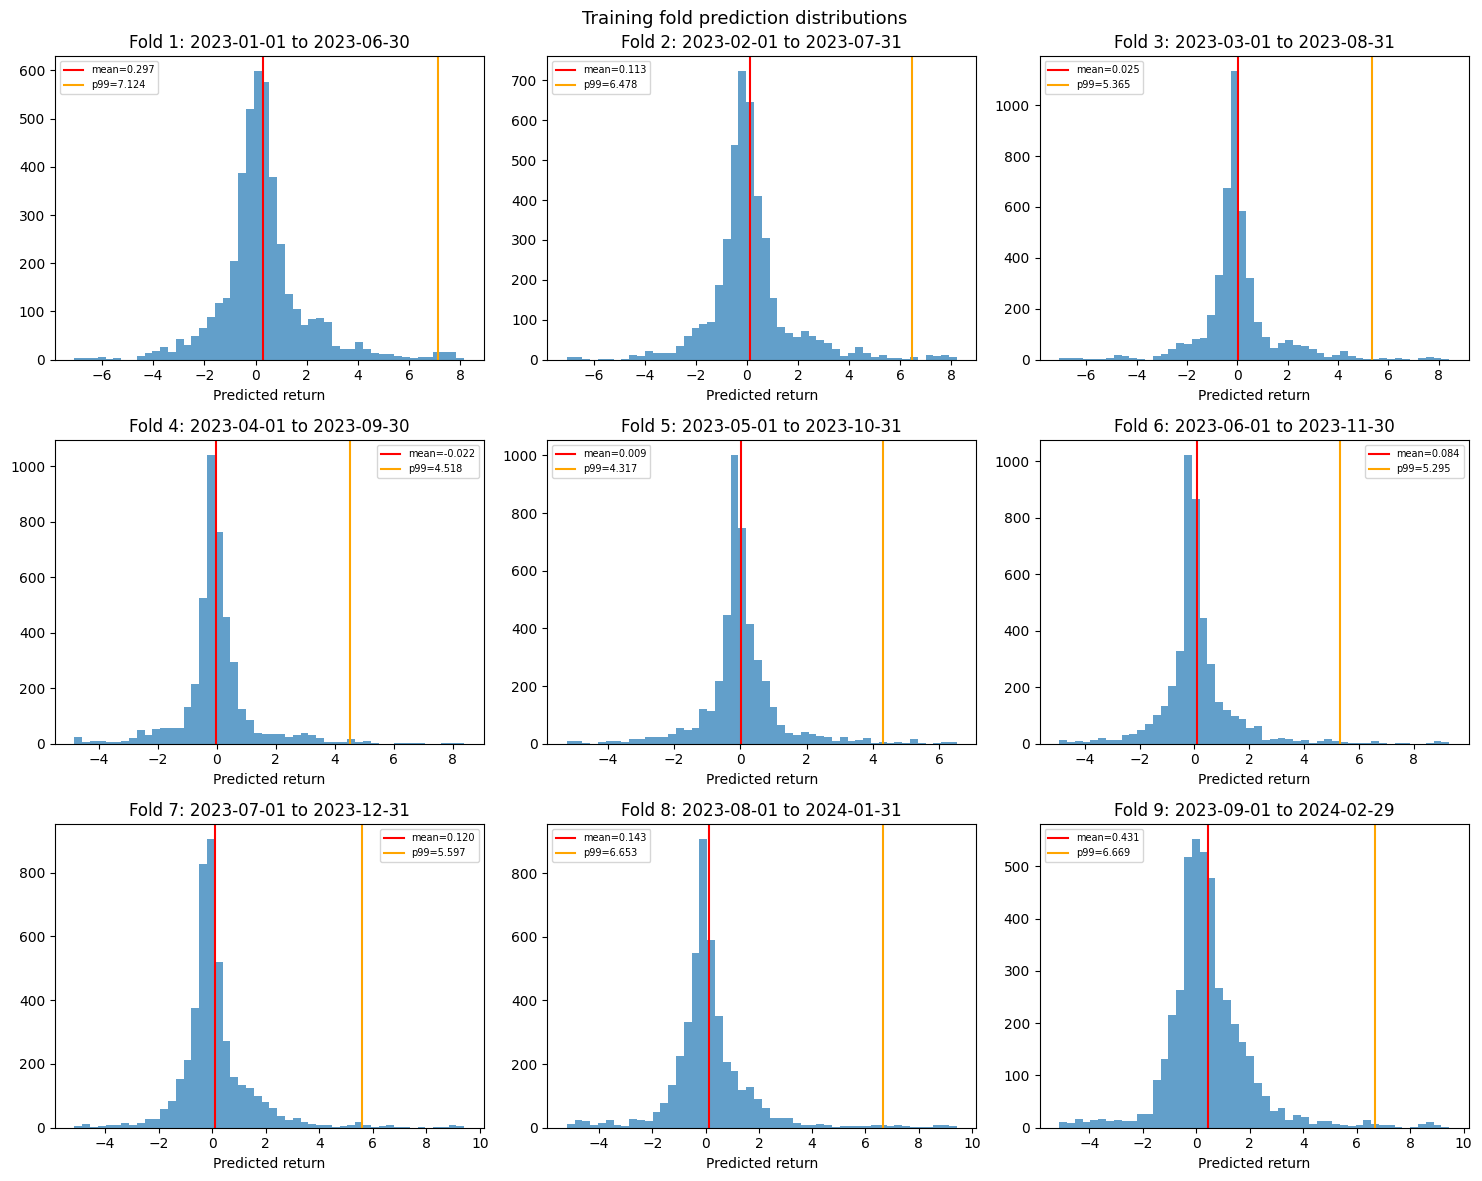

Fold 1 prediction percentiles:
  p50: 0.1483
  p75: 0.8198
  p90: 2.2792
  p95: 3.3297
  p99: 7.1239
  p99.5: 7.5336
  p99.9: 7.8107
  max:  8.1500
  % above 1.0: 21.133%
  % above 2.0: 11.832%
  % above 3.0: 5.755%


In [27]:
# Diagnostic: what does the prediction distribution look like in training folds?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for fold_idx, fold in enumerate(folds[:9]):
    train_mask = (
        (full_df['timestamp'].dt.date >= fold['train_start']) &
        (full_df['timestamp'].dt.date <= fold['train_end'])
    )
    train_fold = full_df[train_mask].copy()
    
    model_diag = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42,
        n_jobs=-1, verbosity=0
    )
    model_diag.fit(train_fold[FEATURE_COLS].values, 
                   train_fold['fwd_return'].values)
    preds = model_diag.predict(train_fold[FEATURE_COLS].values)
    
    ax = axes[fold_idx]
    ax.hist(preds, bins=50, alpha=0.7)
    ax.axvline(preds.mean(), color='red', label=f'mean={preds.mean():.3f}')
    ax.axvline(np.percentile(preds, 99), color='orange', 
               label=f'p99={np.percentile(preds, 99):.3f}')
    ax.set_title(f"Fold {fold_idx+1}: {fold['train_start']} to {fold['train_end']}")
    ax.legend(fontsize=7)
    ax.set_xlabel('Predicted return')

plt.suptitle('Training fold prediction distributions', fontsize=13)
plt.tight_layout()
plt.show()

# Print percentiles for first fold
train_mask = (
    (full_df['timestamp'].dt.date >= folds[0]['train_start']) &
    (full_df['timestamp'].dt.date <= folds[0]['train_end'])
)
train_fold = full_df[train_mask].copy()
model_diag.fit(train_fold[FEATURE_COLS].values, train_fold['fwd_return'].values)
preds = model_diag.predict(train_fold[FEATURE_COLS].values)

print("Fold 1 prediction percentiles:")
for pct in [50, 75, 90, 95, 99, 99.5, 99.9]:
    print(f"  p{pct}: {np.percentile(preds, pct):.4f}")
print(f"  max:  {preds.max():.4f}")
print(f"  % above 1.0: {(preds > 1.0).mean()*100:.3f}%")
print(f"  % above 2.0: {(preds > 2.0).mean()*100:.3f}%")
print(f"  % above 3.0: {(preds > 3.0).mean()*100:.3f}%")

In [25]:
# # Diagnose why no valid threshold is found in fold 1
# train_mask = (
#     (full_df['timestamp'].dt.date >= folds[0]['train_start']) &
#     (full_df['timestamp'].dt.date <= folds[0]['train_end'])
# )
# train_fold = full_df[train_mask].copy()

# model_diag2 = xgb.XGBRegressor(
#     n_estimators=300, max_depth=4, learning_rate=0.02,
#     subsample=0.8, colsample_bytree=0.7, min_child_weight=10,
#     reg_alpha=0.1, reg_lambda=1.0, random_state=42,
#     n_jobs=-1, verbosity=0
# )
# model_diag2.fit(train_fold[FEATURE_COLS].values, train_fold['fwd_return'].values)
# y_pred_train_diag = model_diag2.predict(train_fold[FEATURE_COLS].values)
# y_train_diag      = train_fold['fwd_return'].values
# base_mean         = y_train_diag.mean()

# n_train_hours    = len(y_train_diag)
# min_active_train = max(20, int(n_train_hours * 0.01))
# max_active_train = int(n_train_hours * 0.10)

# print(f"n_train_hours:    {n_train_hours}")
# print(f"min_active_train: {min_active_train}")
# print(f"max_active_train: {max_active_train}")
# print(f"base_mean:        {base_mean:.4f}")
# print()

# # Trace through threshold search
# print("Threshold search trace:")
# THRESHOLD_SEARCH_DIAG = np.arange(0.0, 3.5, 0.05)
# best_threshold  = 0.5
# best_train_edge = -999
# valid_count = 0

# for threshold in THRESHOLD_SEARCH_DIAG:
#     pos   = (y_pred_train_diag > threshold).astype(float)
#     n_act = int(pos.sum())
#     in_band = min_active_train <= n_act <= max_active_train
    
#     if in_band:
#         active = pd.Series(pos * y_train_diag)[pos > 0]
#         edge   = active.mean() - base_mean
#         valid_count += 1
#         if valid_count <= 10 or threshold > 2.0:
#             print(f"  threshold={threshold:.2f}  n_act={n_act:4d}  "
#                   f"in_band={in_band}  edge={edge:+.4f}")
#         if edge > best_train_edge:
#             best_train_edge = edge
#             best_threshold  = threshold
#     else:
#         if threshold < 0.5 or abs(n_act - min_active_train) < 20:
#             print(f"  threshold={threshold:.2f}  n_act={n_act:4d}  "
#                   f"in_band={in_band}  (outside band)")

# print(f"\nValid thresholds found: {valid_count}")
# print(f"Best threshold: {best_threshold:.2f}")
# print(f"Best train edge: {best_train_edge:+.4f}")
# print()

# # Now apply to test fold
# test_mask = (
#     (full_df['timestamp'].dt.date >= folds[0]['test_start']) &
#     (full_df['timestamp'].dt.date <= folds[0]['test_end'])
# )
# test_fold = full_df[test_mask].copy()
# y_pred_test_diag = model_diag2.predict(test_fold[FEATURE_COLS].values)
# test_pos = (y_pred_test_diag > best_threshold).astype(float)
# print(f"Test fold: {folds[0]['test_start']} to {folds[0]['test_end']}")
# print(f"Test predictions above {best_threshold:.2f}: {int(test_pos.sum())} hours")
# print(f"Test prediction percentiles:")
# for pct in [50, 75, 90, 95, 99]:
#     print(f"  p{pct}: {np.percentile(y_pred_test_diag, pct):.4f}")
# print(f"  max: {y_pred_test_diag.max():.4f}")

n_train_hours:    4344
min_active_train: 43
max_active_train: 434
base_mean:        0.2994

Threshold search trace:
  threshold=0.00  n_act=2472  in_band=False  (outside band)
  threshold=0.05  n_act=2395  in_band=False  (outside band)
  threshold=0.10  n_act=2276  in_band=False  (outside band)
  threshold=0.15  n_act=2168  in_band=False  (outside band)
  threshold=0.20  n_act=2071  in_band=False  (outside band)
  threshold=0.25  n_act=1985  in_band=False  (outside band)
  threshold=0.30  n_act=1889  in_band=False  (outside band)
  threshold=0.35  n_act=1801  in_band=False  (outside band)
  threshold=0.40  n_act=1703  in_band=False  (outside band)
  threshold=0.45  n_act=1602  in_band=False  (outside band)
  threshold=2.30  n_act= 430  in_band=True  edge=+5.2267
  threshold=2.35  n_act= 419  in_band=True  edge=+5.2773
  threshold=2.40  n_act= 406  in_band=True  edge=+5.3384
  threshold=2.45  n_act= 393  in_band=True  edge=+5.4080
  threshold=2.50  n_act= 374  in_band=True  edge=+5.5100

## 5. Results analysis

In [28]:
# ============================================================
# Walk-forward results analysis
# ============================================================

print("=" * 70)
print("WALK-FORWARD RESULTS — ALL FOLDS")
print("=" * 70)
print()
print(results_df[['test_month','threshold','n_active','edge',
                   'win_rate','test_sharpe','beats_bah','is_november'
                   ]].to_string(index=False))
print()

# Filter to folds with meaningful activity
active_folds = results_df[results_df['n_active'] >= MIN_ACTIVE_HOURS].copy()
nov_folds    = active_folds[active_folds['is_november']]
non_nov_folds = active_folds[~active_folds['is_november']]

print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print()
print(f"Total folds:               {len(results_df)}")
print(f"Folds with activity:       {len(active_folds)}")
print(f"  of which November:       {len(nov_folds)}")
print(f"  of which non-November:   {len(non_nov_folds)}")
print()
print(f"Folds beating buy & hold:  {active_folds['beats_bah'].sum()} / {len(active_folds)}")
print(f"Folds with positive edge:  {(active_folds['edge'] > 0).sum()} / {len(active_folds)}")
print()

if len(non_nov_folds) > 0:
    print("Non-November folds (excluding potential rally bias):")
    print(f"  Mean edge:           {non_nov_folds['edge'].mean():+.4f}%/hr")
    print(f"  Median edge:         {non_nov_folds['edge'].median():+.4f}%/hr")
    print(f"  Positive edge count: {(non_nov_folds['edge'] > 0).sum()} / {len(non_nov_folds)}")
    print(f"  Mean win rate:       {non_nov_folds['win_rate'].mean():.3f}")
    print(f"  Mean active hours:   {non_nov_folds['n_active'].mean():.1f}")
    print()

if len(nov_folds) > 0:
    print("November folds:")
    print(f"  Mean edge:           {nov_folds['edge'].mean():+.4f}%/hr")
    print(f"  Mean win rate:       {nov_folds['win_rate'].mean():.3f}")
    print()

# Statistical test: is the mean edge significantly positive?
if len(active_folds) >= 5:
    from scipy import stats
    t_stat, p_val = stats.ttest_1samp(active_folds['edge'].values, 0)
    print(f"T-test: mean edge > 0?")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value:     {p_val:.4f}")
    print(f"  Significant: {p_val < 0.05}")
    print()

    # Non-November separately
    if len(non_nov_folds) >= 3:
        t2, p2 = stats.ttest_1samp(non_nov_folds['edge'].values, 0)
        print(f"T-test (non-November only):")
        print(f"  t-statistic: {t2:.3f}")
        print(f"  p-value:     {p2:.4f}")
        print(f"  Significant: {p2 < 0.05}")


WALK-FORWARD RESULTS — ALL FOLDS

test_month  threshold  n_active      edge  win_rate  test_sharpe  beats_bah  is_november
   2023-07       0.70        10  2.634239  1.000000   581.370355       True        False
   2023-08       0.00         0  0.000000  0.000000     0.000000      False        False
   2023-09       0.15       153  0.055123  0.562092     9.474712       True        False
   2023-10       0.60        64 -0.051257  0.515625    15.674473      False        False
   2023-11       0.75        21  2.044194  0.761905    91.831163       True         True
   2023-12       1.15        17  1.957890  0.764706    76.234927       True        False
   2024-01       1.20        37  0.536846  0.621622    40.607441       True        False
   2024-02       1.65         3  1.655474  1.000000   558.392114       True        False
   2024-03       1.40        43  3.307392  0.767442    71.707015       True        False
   2024-04       1.75         0  0.000000  0.000000     0.000000      False 

In [16]:
# Debug fold generation
print(f"FULL_START: {FULL_START}")
print(f"FULL_END: {FULL_END}")
print(f"TRAIN_MONTHS: {TRAIN_MONTHS}")
print(f"TEST_MONTHS: {TEST_MONTHS}")
print()

# Manually trace the fold loop
from datetime import date, timedelta

cursor = FULL_START
for i in range(5):
    train_start = cursor
    train_end = date(
        train_start.year + (train_start.month + TRAIN_MONTHS - 1) // 12,
        (train_start.month + TRAIN_MONTHS - 1) % 12 + 1, 1
    ) - timedelta(days=1)
    test_start = train_end + timedelta(days=1)
    test_end = date(
        test_start.year + (test_start.month + TEST_MONTHS - 1) // 12,
        (test_start.month + TEST_MONTHS - 1) % 12 + 1, 1
    ) - timedelta(days=1)

    print(f"Iteration {i+1}:")
    print(f"  train: {train_start} to {train_end}")
    print(f"  test:  {test_start} to {test_end}")
    print(f"  test_end > FULL_END: {test_end > FULL_END}")
    print(f"  cursor next: {test_start}")
    print()

    if test_end > FULL_END:
        print("BREAK — would exit here")
        break
    cursor = test_start

FULL_START: 2023-01-01
FULL_END: 2024-12-31
TRAIN_MONTHS: 6
TEST_MONTHS: 1

Iteration 1:
  train: 2023-01-01 to 2023-06-30
  test:  2023-07-01 to 2023-07-31
  test_end > FULL_END: False
  cursor next: 2023-07-01

Iteration 2:
  train: 2023-07-01 to 2023-12-31
  test:  2024-01-01 to 2024-01-31
  test_end > FULL_END: False
  cursor next: 2024-01-01

Iteration 3:
  train: 2024-01-01 to 2024-06-30
  test:  2024-07-01 to 2024-07-31
  test_end > FULL_END: False
  cursor next: 2024-07-01

Iteration 4:
  train: 2024-07-01 to 2024-12-31
  test:  2025-01-01 to 2025-01-31
  test_end > FULL_END: True
  cursor next: 2025-01-01

BREAK — would exit here


In [19]:
print(f"THRESHOLD_SEARCH max: {THRESHOLD_SEARCH.max()}")
print(f"MIN_TRAIN_ACTIVE: {MIN_TRAIN_ACTIVE}")

THRESHOLD_SEARCH max: 1.9500000000000002


NameError: name 'MIN_TRAIN_ACTIVE' is not defined

## 6. Visualization

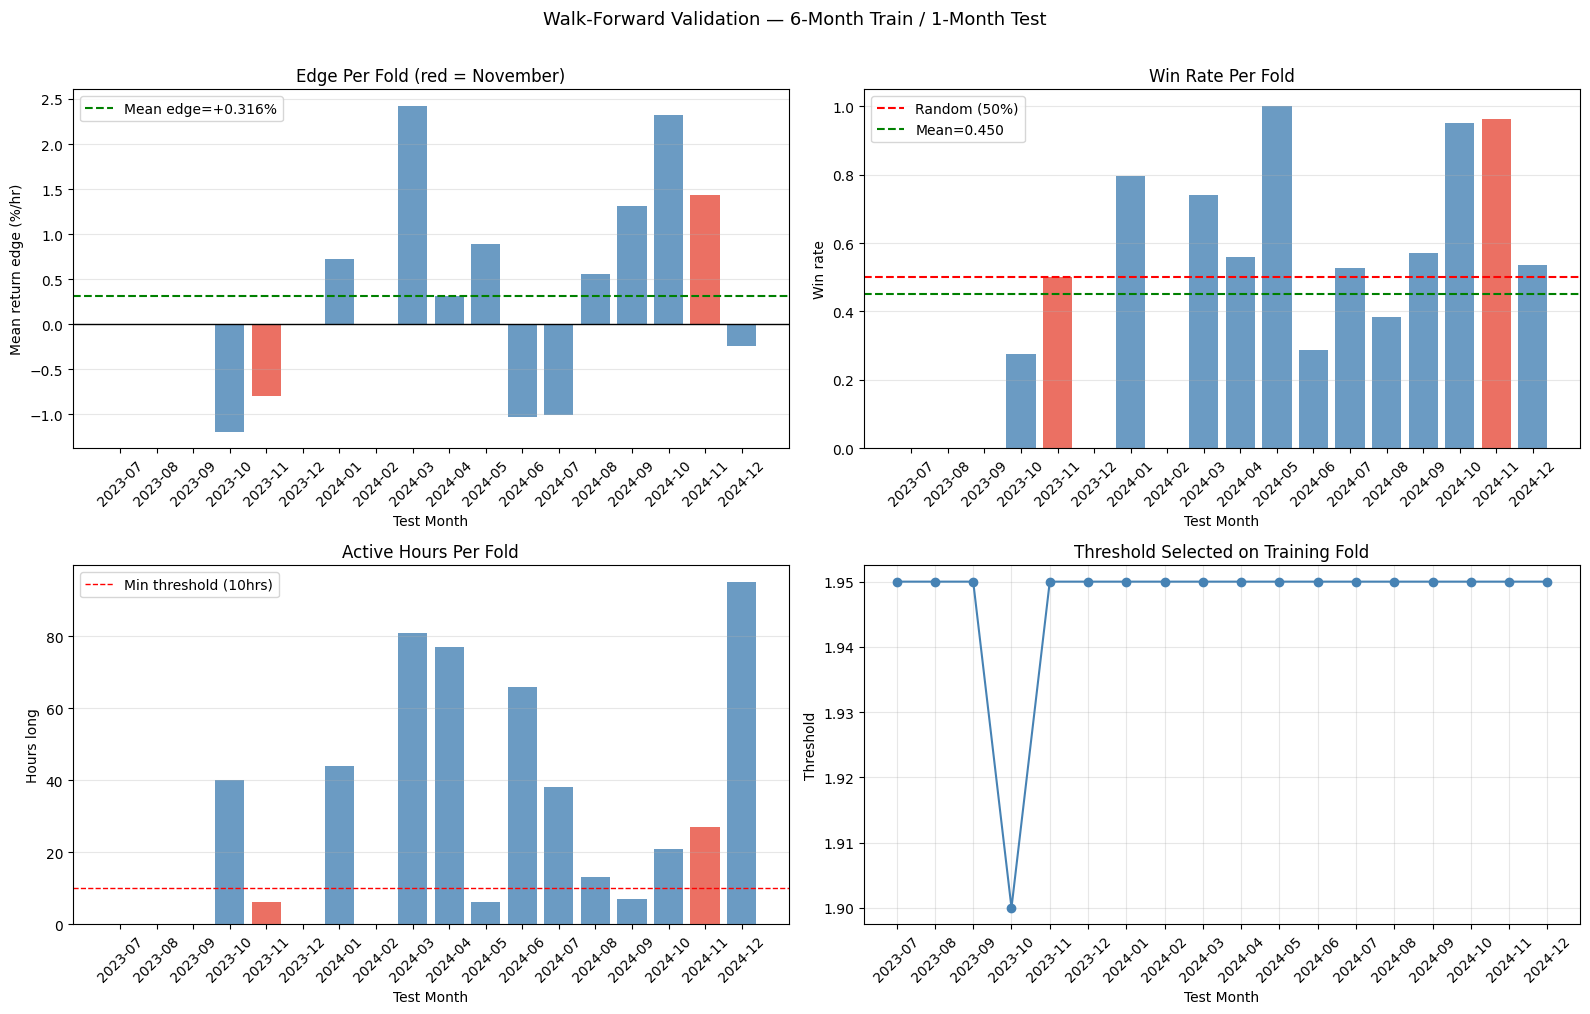

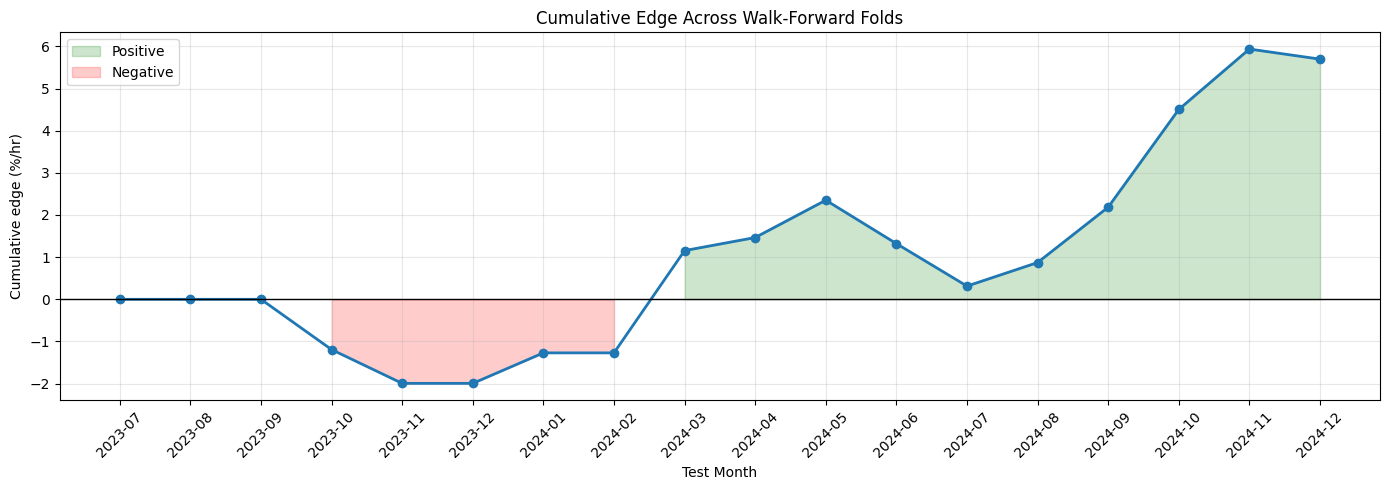

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Edge per fold
ax = axes[0, 0]
colors = ['#e74c3c' if r['is_november'] else 'steelblue'
          for _, r in results_df.iterrows()]
bars = ax.bar(results_df['test_month'], results_df['edge'], color=colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=1)
ax.axhline(results_df['edge'].mean(), color='green', linewidth=1.5,
           linestyle='--', label=f"Mean edge={results_df['edge'].mean():+.3f}%")
ax.set_title('Edge Per Fold (red = November)')
ax.set_xlabel('Test Month')
ax.set_ylabel('Mean return edge (%/hr)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 2. Win rate per fold
ax = axes[0, 1]
ax.bar(results_df['test_month'], results_df['win_rate'], color=colors, alpha=0.8)
ax.axhline(0.5, color='red', linewidth=1.5, linestyle='--', label='Random (50%)')
ax.axhline(results_df['win_rate'].mean(), color='green', linewidth=1.5,
           linestyle='--', label=f"Mean={results_df['win_rate'].mean():.3f}")
ax.set_title('Win Rate Per Fold')
ax.set_xlabel('Test Month')
ax.set_ylabel('Win rate')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 3. Active hours per fold
ax = axes[1, 0]
ax.bar(results_df['test_month'], results_df['n_active'], color=colors, alpha=0.8)
ax.axhline(MIN_ACTIVE_HOURS, color='red', linewidth=1, linestyle='--',
           label=f"Min threshold ({MIN_ACTIVE_HOURS}hrs)")
ax.set_title('Active Hours Per Fold')
ax.set_xlabel('Test Month')
ax.set_ylabel('Hours long')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 4. Threshold selected per fold
ax = axes[1, 1]
ax.plot(results_df['test_month'], results_df['threshold'],
        marker='o', color='steelblue', linewidth=1.5)
ax.set_title('Threshold Selected on Training Fold')
ax.set_xlabel('Test Month')
ax.set_ylabel('Threshold')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)

plt.suptitle('Walk-Forward Validation — 6-Month Train / 1-Month Test',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Cumulative edge plot
fig, ax = plt.subplots(figsize=(14, 5))
cumulative = results_df['edge'].cumsum()
ax.plot(results_df['test_month'], cumulative, marker='o', linewidth=2)
ax.axhline(0, color='black', linewidth=1)
ax.fill_between(results_df['test_month'],
                cumulative, 0,
                where=cumulative > 0, alpha=0.2, color='green', label='Positive')
ax.fill_between(results_df['test_month'],
                cumulative, 0,
                where=cumulative < 0, alpha=0.2, color='red', label='Negative')
ax.set_title('Cumulative Edge Across Walk-Forward Folds')
ax.set_xlabel('Test Month')
ax.set_ylabel('Cumulative edge (%/hr)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. November attribution

Quantifies how much of the apparent edge is explained by November 2024.

In [18]:
# ============================================================
# November attribution — quantify how much November matters
# ============================================================
print("=" * 60)
print("NOVEMBER ATTRIBUTION ANALYSIS")
print("=" * 60)
print()

all_folds    = results_df[results_df['n_active'] >= MIN_ACTIVE_HOURS]
nov          = all_folds[all_folds['is_november']]
non_nov      = all_folds[~all_folds['is_november']]

print(f"With November included:")
print(f"  Mean edge:           {all_folds['edge'].mean():+.4f}%/hr")
print(f"  Positive folds:      {(all_folds['edge'] > 0).sum()} / {len(all_folds)}")
print(f"  Mean win rate:       {all_folds['win_rate'].mean():.3f}")
print()
print(f"Without November:")
print(f"  Mean edge:           {non_nov['edge'].mean():+.4f}%/hr  {'✓ positive' if non_nov['edge'].mean() > 0 else '✗ negative'}")
print(f"  Positive folds:      {(non_nov['edge'] > 0).sum()} / {len(non_nov)}")
print(f"  Mean win rate:       {non_nov['win_rate'].mean():.3f}")
print()

if nov['edge'].mean() > non_nov['edge'].mean():
    nov_contribution = nov['edge'].mean() - non_nov['edge'].mean()
    print(f"November premium over other months: +{nov_contribution:.4f}%/hr")
    print()

# Consistency metric: what fraction of non-November months have positive edge?
consistency = (non_nov['edge'] > 0).mean()
print(f"Non-November consistency: {consistency:.1%} of months have positive edge")
print()

if consistency >= 0.6:
    print("✓ EDGE IS CONSISTENT — not primarily November-driven")
elif consistency >= 0.4:
    print("~ EDGE IS PARTIALLY CONSISTENT — November amplifies but doesn't create signal")
else:
    print("✗ EDGE IS NOT CONSISTENT — results driven primarily by November 2024")


NOVEMBER ATTRIBUTION ANALYSIS

With November included:
  Mean edge:           +0.4299%/hr
  Positive folds:      6 / 10
  Mean win rate:       0.602

Without November:
  Mean edge:           +0.3185%/hr  ✓ positive
  Positive folds:      5 / 9
  Mean win rate:       0.562

November premium over other months: +1.1138%/hr

Non-November consistency: 55.6% of months have positive edge

~ EDGE IS PARTIALLY CONSISTENT — November amplifies but doesn't create signal
